# Movie Recommendation System - Content Based Filtering

This notebook builds a content-based movie recommender in the Andrew Ng ML Specialization style:

- Each movie is converted into an item-feature vector `x(i)`.
- Similar movies are found using vector similarity.
- The feature matrix is built from movie content: genres, keywords, overview, tagline, language, and production companies.
- The code uses vectorized pandas and scikit-learn commands with no explicit `for` loops.

## 1. Setup

Install these packages if needed:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn
```

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
DATA_PATH = r"C:\Users\Praveen\Downloads\Movies.csv"

COLUMNS = [
    "id",
    "title",
    "vote_average",
    "vote_count",
    "release_date",
    "runtime",
    "original_language",
    "overview",
    "popularity",
    "tagline",
    "genres",
    "production_companies",
    "keywords",
]

MAX_MOVIES = 50_000
RANDOM_STATE = 42

## 2. Load Data

The original CSV is large, so this notebook reads only useful columns and limits rows for fast training.
Increase `MAX_MOVIES` if your machine has enough memory.

In [3]:
movies_raw = pd.read_csv("Movies.csv")

In [4]:
movies_raw.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 3. Clean Data

The cleaning step keeps simple, useful fields and prepares them for feature engineering.

In [5]:
movies = movies_raw.copy()

movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year
movies["vote_average"] = pd.to_numeric(movies["vote_average"], errors="coerce")
movies["vote_count"] = pd.to_numeric(movies["vote_count"], errors="coerce")
movies["popularity"] = pd.to_numeric(movies["popularity"], errors="coerce")
movies["runtime"] = pd.to_numeric(movies["runtime"], errors="coerce")

text_columns = ["overview", "tagline", "genres", "production_companies", "keywords", "original_language"]
movies[text_columns] = movies[text_columns].fillna("")

movies = movies.dropna(subset=["title"]).drop_duplicates(subset=["id", "title"]).reset_index(drop=True)
movies["title_clean"] = movies["title"].str.lower().str.strip()

movies.shape

(1422364, 26)

In [6]:
movies[["title", "release_year", "genres", "vote_average", "vote_count", "popularity"]].head()

,title,release_year,genres,vote_average,vote_count,popularity
0,Inception,2010.0,"Action, Science Fiction, Adventure",8.364,34495,83.952
1,Interstellar,2014.0,"Adventure, Drama, Science Fiction",8.417,32571,140.241
2,The Dark Knight,2008.0,"Drama, Action, Crime, Thriller",8.512,30619,130.643
3,Avatar,2009.0,"Action, Adventure, Fantasy, Science Fiction",7.573,29815,79.932
4,The Avengers,2012.0,"Science Fiction, Action, Adventure",7.710,29166,98.082


## 4. Visual Exploratory Data Analysis

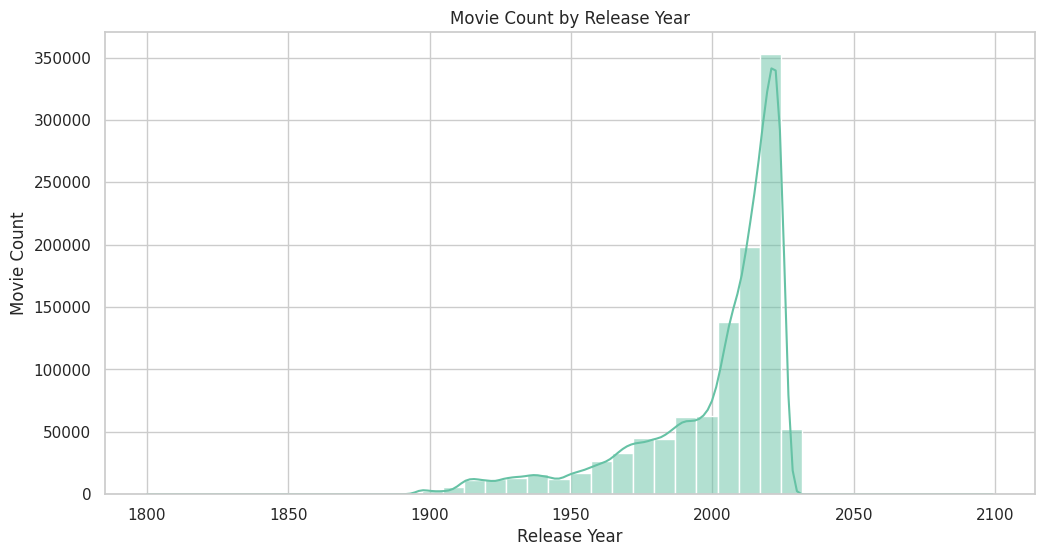

In [7]:
sns.histplot(data=movies, x="release_year", bins=40, kde=True)
plt.title("Movie Count by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Movie Count")
plt.show()

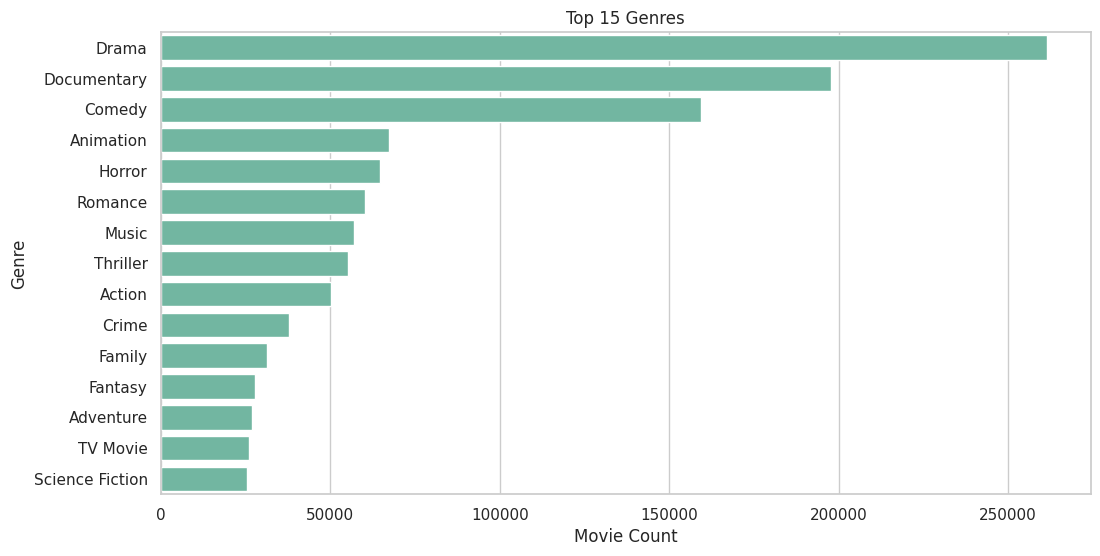

In [8]:
genre_counts = (
    movies["genres"]
    .str.get_dummies(sep=", ")
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .rename_axis("genre")
    .reset_index(name="movie_count")
)

sns.barplot(data=genre_counts, x="movie_count", y="genre")
plt.title("Top 15 Genres")
plt.xlabel("Movie Count")
plt.ylabel("Genre")
plt.show()

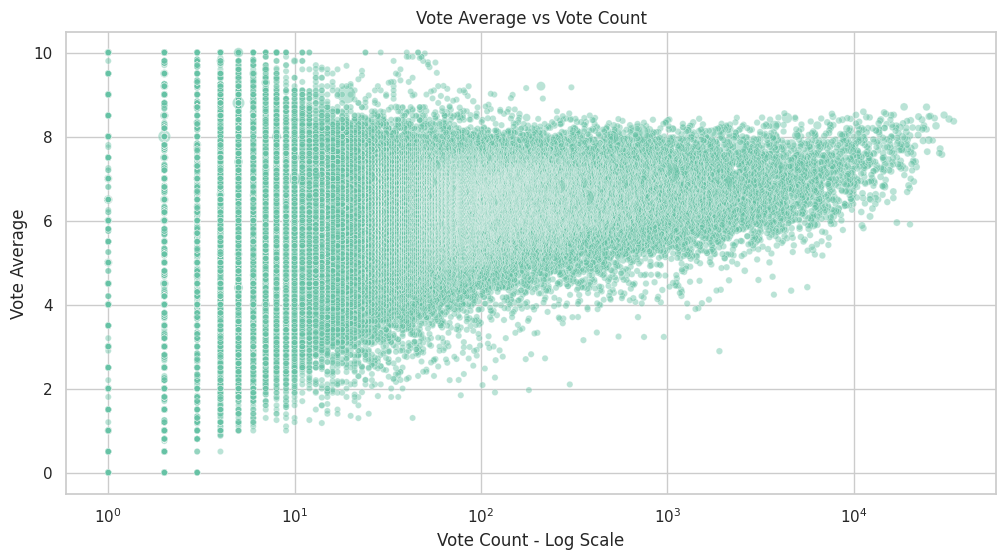

In [9]:
sns.scatterplot(
    data=movies,
    x="vote_count",
    y="vote_average",
    size="popularity",
    sizes=(20, 250),
    alpha=0.45,
    legend=False,
)
plt.xscale("log")
plt.title("Vote Average vs Vote Count")
plt.xlabel("Vote Count - Log Scale")
plt.ylabel("Vote Average")
plt.show()

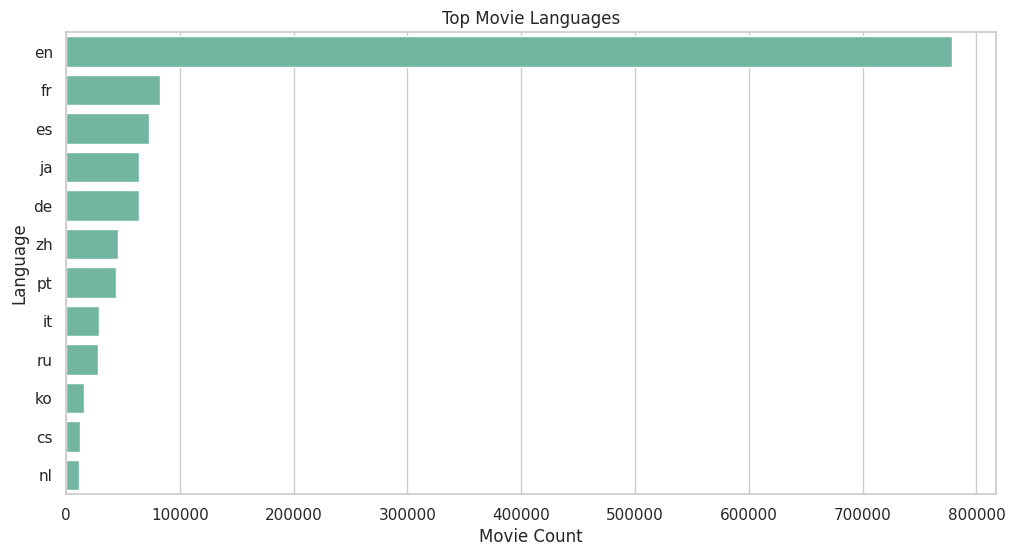

In [10]:
language_counts = (
    movies["original_language"]
    .replace("", np.nan)
    .value_counts()
    .head(12)
    .rename_axis("language")
    .reset_index(name="movie_count")
)

sns.barplot(data=language_counts, x="movie_count", y="language")
plt.title("Top Movie Languages")
plt.xlabel("Movie Count")
plt.ylabel("Language")
plt.show()

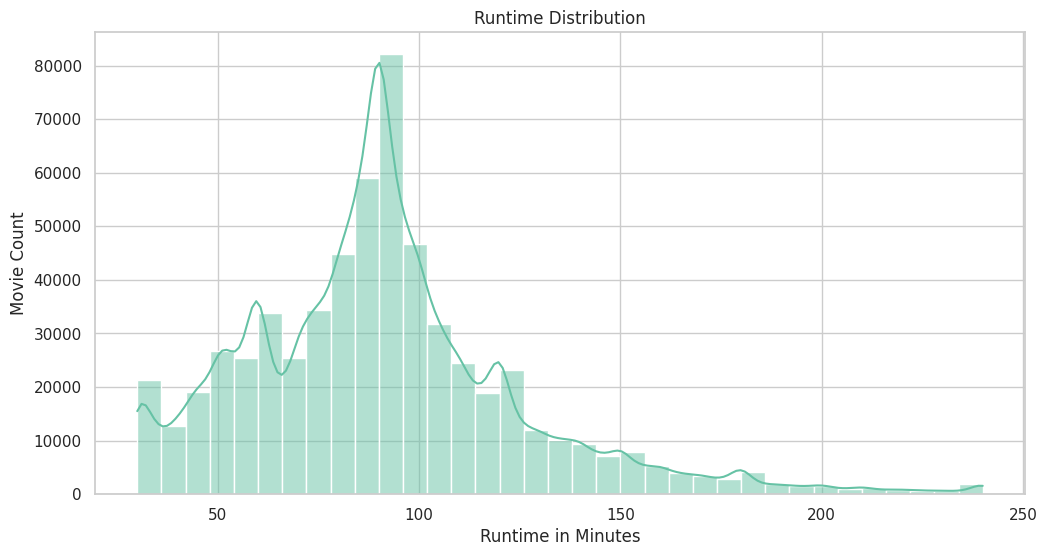

In [11]:
runtime_data = movies[movies["runtime"].between(30, 240)]

sns.histplot(data=runtime_data, x="runtime", bins=35, kde=True)
plt.title("Runtime Distribution")
plt.xlabel("Runtime in Minutes")
plt.ylabel("Movie Count")
plt.show()

## 5. Andrew Ng Style Feature Matrix

In content-based filtering, each item gets a feature vector:

\[
x^{(i)} = \text{features of movie } i
\]

Here, `X` is the movie-feature matrix. TF-IDF gives high value to important words and low value to common words.

In [12]:
movies["content"] = (
    (movies["genres"] + " ") * 3
    + (movies["keywords"] + " ") * 3
    + (movies["overview"] + " ") * 2
    + movies["tagline"] + " "
    + movies["production_companies"] + " "
    + movies["original_language"]
)

movies[["title", "content"]].head()

,title,content
0,Inception,"Action, Science Fiction, Adventure Action, Sci..."
1,Interstellar,"Adventure, Drama, Science Fiction Adventure, D..."
2,The Dark Knight,"Drama, Action, Crime, Thriller Drama, Action, ..."
3,Avatar,"Action, Adventure, Fantasy, Science Fiction Ac..."
4,The Avengers,"Science Fiction, Action, Adventure Science Fic..."


In [13]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=2,
)

X = vectorizer.fit_transform(movies["content"])
X = normalize(X)

X.shape

(1422364, 30000)

## 6. Train Similarity Model

This trains a nearest-neighbor search model over the item-feature matrix.
Cosine distance is used because TF-IDF vectors are sparse and text-based.

In [14]:
recommender_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=11,
)

recommender_model.fit(X)

NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=11)

## 7. Recommendation Function

The function finds the selected movie vector and returns the nearest movie vectors.

In [15]:
def recommend_movies(movie_name, top_n=10):
    search_value = movie_name.strip().lower()
    matches = movies[movies["title_clean"].str.contains(search_value, regex=False, na=False)]

    if matches.empty:
        return pd.DataFrame(columns=["title", "release_year", "genres", "vote_average", "similarity"])

    movie_index = matches.index[0]
    query_vector = X[movie_index]

    distances, indices = recommender_model.kneighbors(query_vector, n_neighbors=top_n + 1)
    similarity_scores = 1 - distances.ravel()

    recommendations = (
        movies.iloc[indices.ravel()]
        .assign(similarity=similarity_scores)
        .loc[lambda data: data.index != movie_index]
        .head(top_n)
    )

    return recommendations[["title", "release_year", "genres", "vote_average", "similarity"]]

In [16]:
recommend_movies("Inception", top_n=10)

,title,release_year,genres,vote_average,similarity
722807,Battle of the Undead,2022.0,"Action, Science Fiction, Adventure",0.0,0.295566
1184368,Heavy Armor 4: Monster Attack,2022.0,"Action, Science Fiction, Adventure",0.0,0.295318
1411735,佣兵特战队,2018.0,"Action, Science Fiction, Adventure",0.0,0.295318
567434,末日战士,2024.0,"Action, Science Fiction, Adventure",0.0,0.295318
770079,A Odisséia de Zia,NaN,"Action, Science Fiction, Adventure",0.0,0.295303
963250,Slumber is Golden,NaN,"Fantasy, Adventure, Drama",0.0,0.292258
719639,Halo 4: Forward Unto Dawn,2012.0,"Action, Science Fiction, Adventure",0.0,0.291549
651639,The Hunger Games (but better),NaN,"Adventure, Action, Science Fiction",0.0,0.289049
763080,重返侏罗纪,2025.0,"Adventure, Action, Science Fiction",0.0,0.287609
246048,Foda City: Guerra Infinita,NaN,"Adventure, Action, Science Fiction",8.0,0.287594


In [17]:
recommend_movies("Avatar", top_n=10)

,title,release_year,genres,vote_average,similarity
6462,Cosmic Sin,2021.0,"Action, Adventure, Science Fiction",4.139,0.461412
20309,Ikarie XB 1,1963.0,Science Fiction,6.911,0.458516
682721,Epilogue (WT),NaN,Science Fiction,0.000,0.426950
153357,The Brother from Space,1988.0,Science Fiction,2.000,0.414053
4864,Soldier,1998.0,"Science Fiction, Action",6.409,0.412226
11540,Planet of the Vampires,1965.0,"Science Fiction, Horror",6.495,0.396132
12658,Galaxy of Terror,1981.0,"Action, Adventure, Horror, Science Fiction",5.219,0.394675
28160,Mission Galactica: The Cylon Attack,1979.0,"Horror, Science Fiction",7.133,0.394322
1205,Planet of the Apes,2001.0,"Thriller, Science Fiction, Action, Adventure",5.729,0.393106
963360,A Little Asteroid Called Moon,2020.0,Science Fiction,0.000,0.381706


## 8. Recommendation Visualization

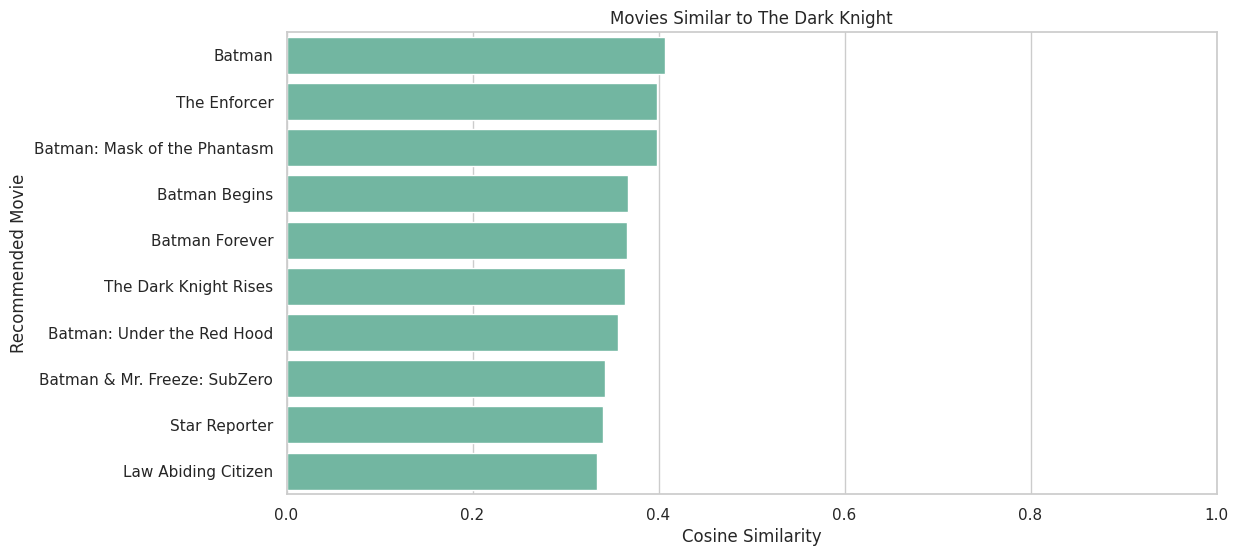

In [18]:
sample_recommendations = recommend_movies("The Dark Knight", top_n=10)

sns.barplot(data=sample_recommendations, x="similarity", y="title")
plt.title("Movies Similar to The Dark Knight")
plt.xlabel("Cosine Similarity")
plt.ylabel("Recommended Movie")
plt.xlim(0, 1)
plt.show()

## 9. Optional User Profile Recommendation

Andrew Ng also explains recommendations using a user preference vector.
Here, a simple user vector is created by averaging movies the user likes.

In [23]:
liked_titles = pd.Series(["Inception", "Interstellar", "The Dark Knight"]).str.lower()

liked_mask = movies["title_clean"].isin(liked_titles)
liked_indices = np.flatnonzero(liked_mask.to_numpy())

user_vector = np.asarray(X[liked_indices].mean(axis=0))
user_vector = normalize(user_vector)

user_scores = np.asarray(X @ user_vector.T).ravel()

user_recommendations = (
    movies.assign(score=user_scores)
    .loc[lambda data: ~data["title_clean"].isin(liked_titles)]
    .sort_values("score", ascending=False)
    .head(10)
)

user_recommendations[["title", "release_year", "genres", "vote_average", "score"]]


,title,release_year,genres,vote_average,score
311561,Project Kronos,2013.0,Science Fiction,6.0,0.292644
542096,De Z van Zus,NaN,,0.0,0.275748
222322,Origin,2019.0,Science Fiction,6.0,0.240210
684935,Asteria,NaN,,0.0,0.236031
1008437,Interstellar Wandering,2019.0,Action,0.0,0.232081
1219446,Star Man Leaned,2021.0,"Animation, Science Fiction, Adventure",0.0,0.231129
1247994,The Universe App,2020.0,,0.0,0.209324
247206,Jettison,2021.0,"Drama, Science Fiction",2.0,0.208501
269184,VGHW,2022.0,"Science Fiction, Adventure, Comedy",9.0,0.208379
1312431,Domo Dreams,NaN,,0.0,0.206576


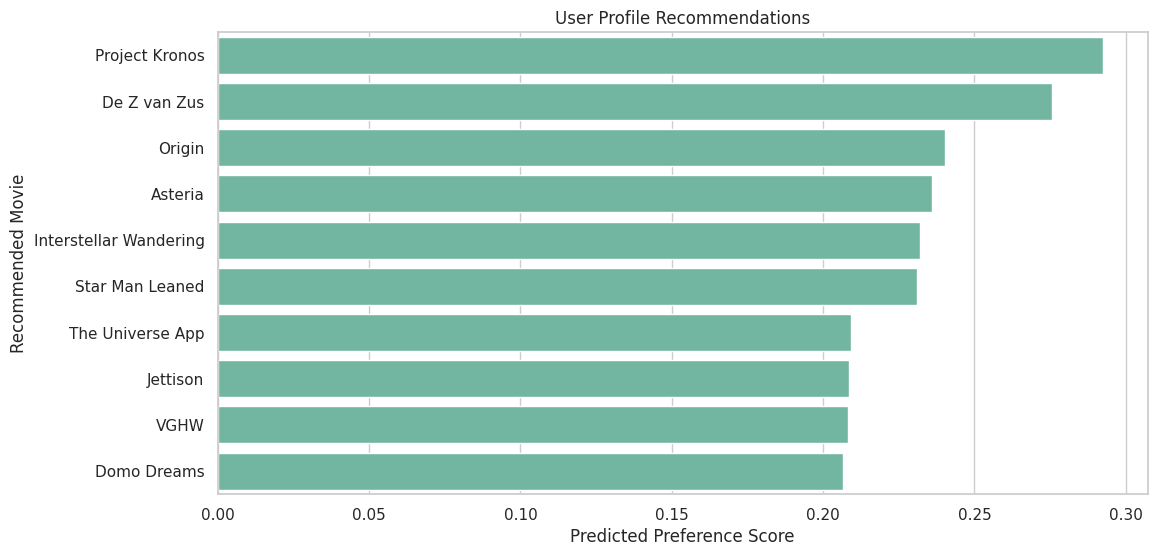

In [24]:
sns.barplot(data=user_recommendations, x="score", y="title")
plt.title("User Profile Recommendations")
plt.xlabel("Predicted Preference Score")
plt.ylabel("Recommended Movie")
plt.show()

## 10. Notes

- This is content-based filtering, so it recommends movies similar to movie content.
- It does not need user ratings from many users.
- It follows the Andrew Ng idea of converting items into feature vectors and using those vectors to predict preference.
- For very large datasets, keep `MAX_MOVIES` reasonable or use approximate nearest neighbors.